In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import sys; sys.path.insert(0, '..')
from utils import parse_latencies, parse_power_log, get_power_index, plot_inference_cycle_power

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_model_loading')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4174621.6927380087


## Resnet18

In this section, we will analyse the power consumption of Resnet18 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'resnet18'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet18_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet18_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/f'{model_name}_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
resnet18_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 30.21it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(resnet18_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet18_latency_data[0])}")
print(f"Number of latency entries for each layer: {len(resnet18_latency_data)}")

Number of power entries for resnet18: 2403045
Number of TensorRT layers in resnet18: 26
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

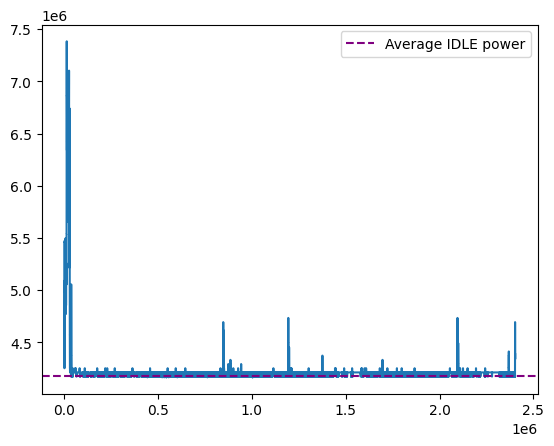

In [6]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
experiment_start_time = datetime.strptime(resnet18_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(resnet18_power_data, experiment_start_time)

pytorch_load_end_time = datetime.strptime(resnet18_data['pt_model_load_end'], "%Y%m%d-%H%M%S")
pytorch_load_end_index = get_power_index(resnet18_power_data, pytorch_load_end_time)

model_load_start_time = datetime.strptime(resnet18_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(resnet18_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(resnet18_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(resnet18_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(resnet18_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(resnet18_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(resnet18_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(resnet18_power_data, warmup_end_time)

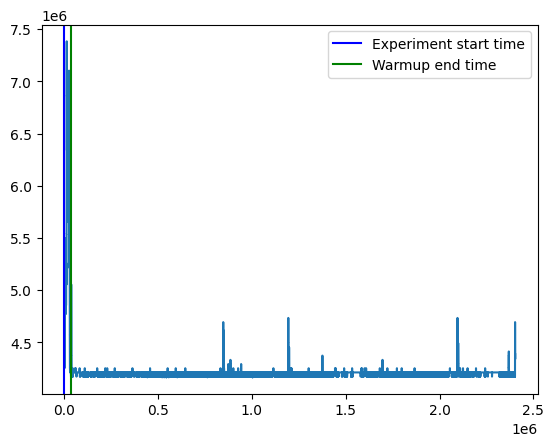

In [8]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

What are things happening in this time?

- We get the PyTorch model downloaded
- Create dummy PyTorch input tensors
- Move both the model and the input tensors to GPU 

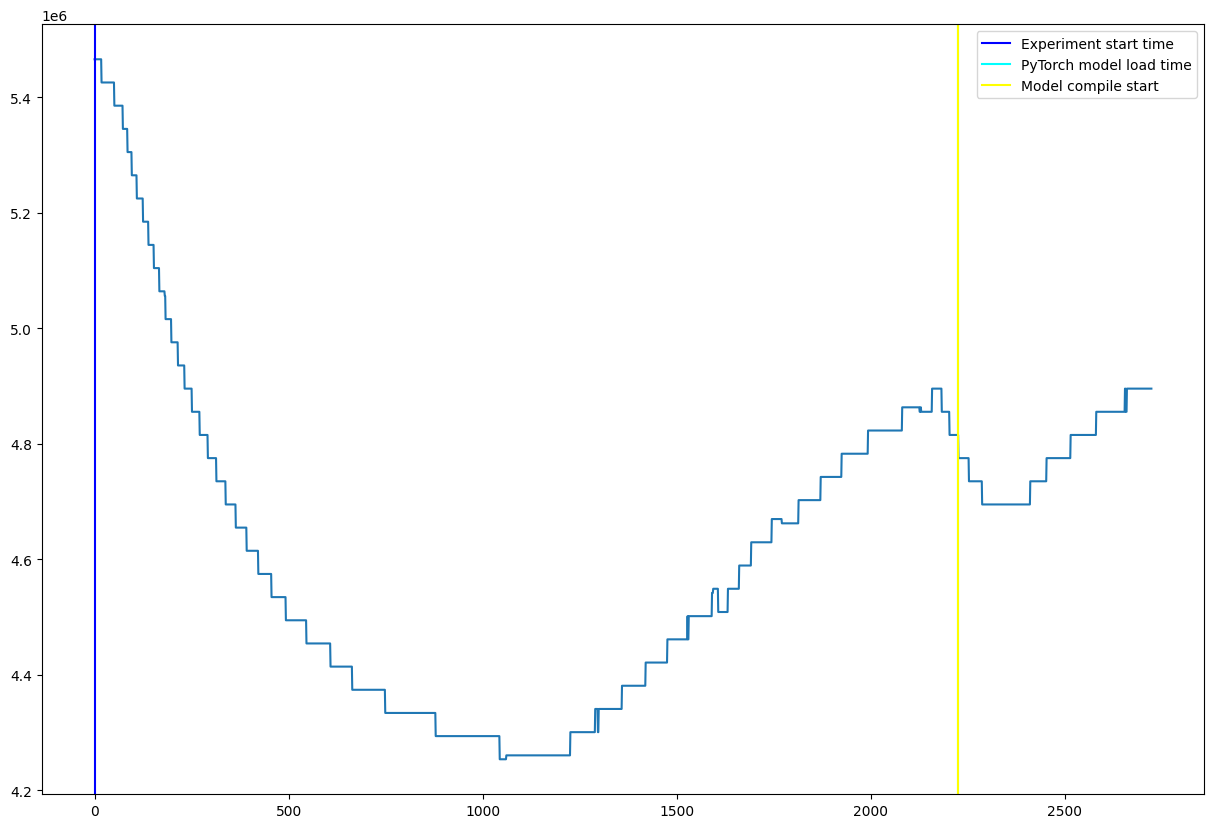

In [9]:
plt.figure(figsize=(15, 10))
plt.plot([power for (timestamp, power) in resnet18_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between purple and green line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4213440.0`.

So we have power value 

- When jeston is idle : 4174621
- When TRT model is loaded: 4213440
- When inference is ran for 3000 runs: 4213440

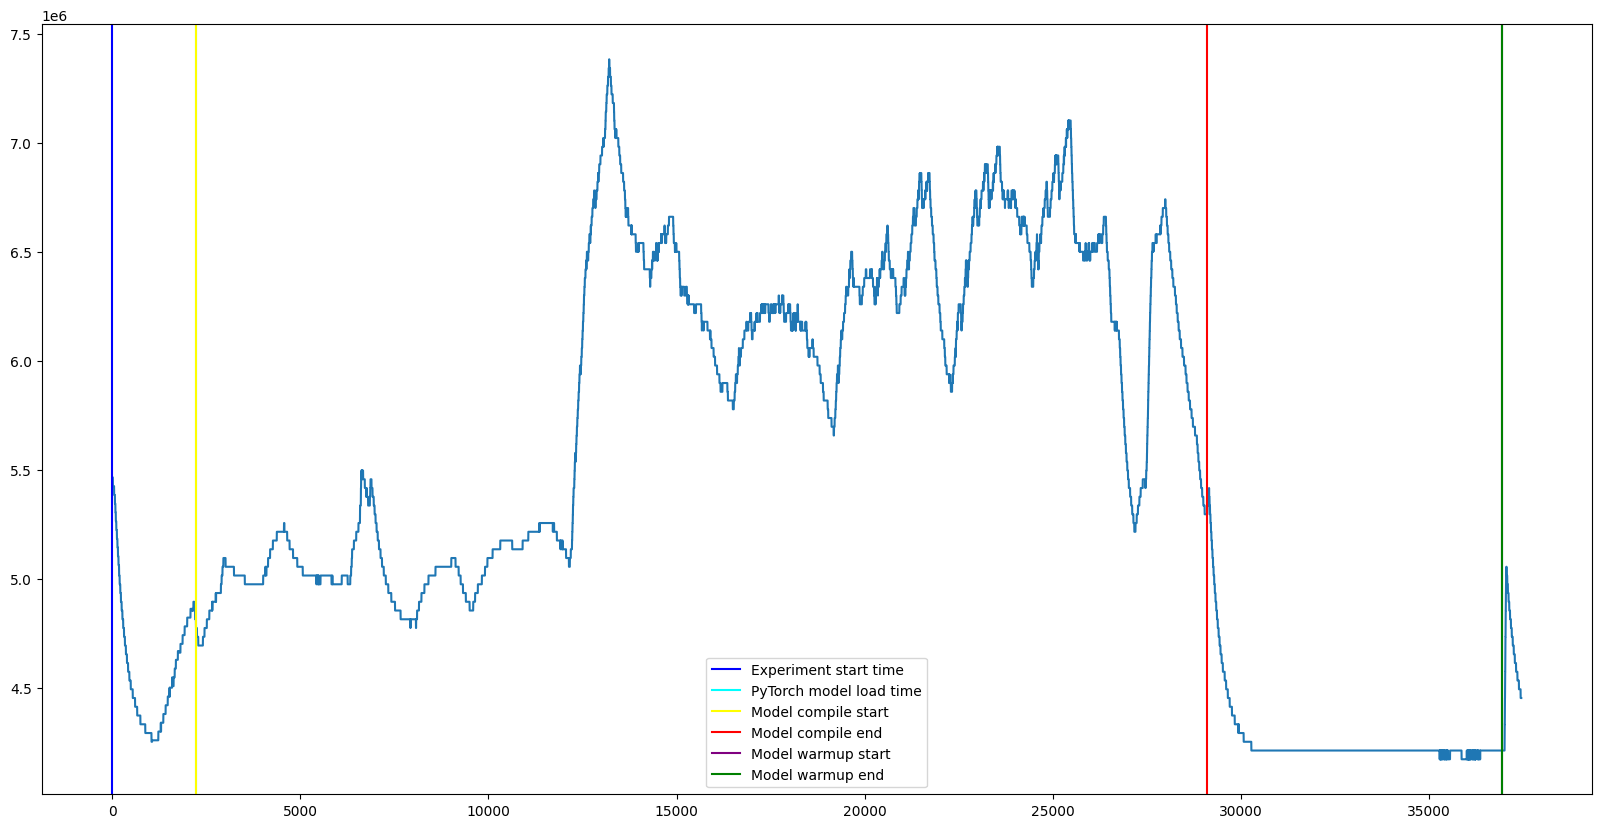

In [10]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in resnet18_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [11]:
print(f'Time taken to download and load the pytorch model: {(pytorch_load_end_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to before the model compile starts and pytorch model is loaded: {(model_load_start_time - pytorch_load_end_time).total_seconds()} seconds')
print(f'Time taken to compile the TensorRT model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup starts: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to download and load the pytorch model: 3.0 seconds
Time taken to before the model compile starts and pytorch model is loaded: 0.0 seconds
Time taken to compile the TensorRT model: 35.0 seconds
Sleep interval before the warmup starts: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


### Power cool down

This is the delay we introduce after the warmup ends and before the first iteration cycle beings for the benchmarking experiment.

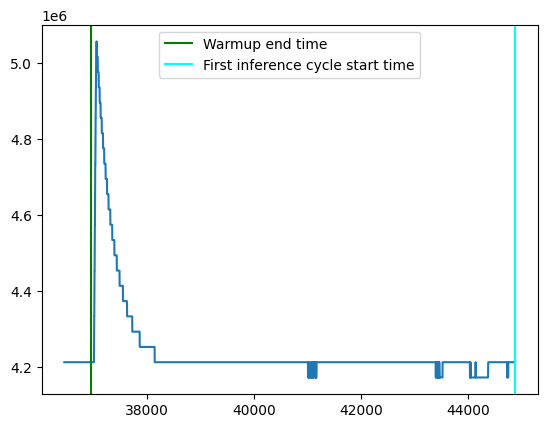

In [12]:
plt.plot(range(warmup_end_index-500, 44876), [power for (timestamp, power) in resnet18_power_data[warmup_end_index-500:44876]])
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.axvline(44876, color='cyan', label='First inference cycle start time')
plt.legend()

### Inference

Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 

> **The power consumed when the inference starts, inference ends and when the delay of 1 second is completed is same for the majority of the runs.** This value is same as power value when TRT model is loaded.

2025-01-22 12:45:08.131492 -> 2025-01-22 12:45:08.132602
2025-01-22 12:45:09.132602
Time taken by inference cycle 0: 0:00:00.001110
Iteration: 0, Power index: 44876 -> 44878
45661


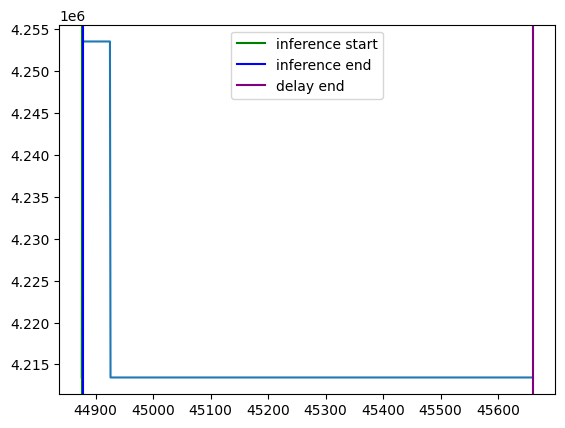

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:09.135639 -> 2025-01-22 12:45:09.136604
2025-01-22 12:45:10.136604
Time taken by inference cycle 1: 0:00:00.000965
Iteration: 1, Power index: 45662 -> 45664
46446


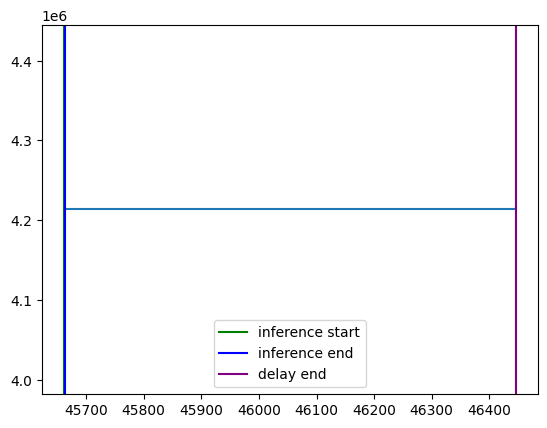

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:10.139402 -> 2025-01-22 12:45:10.140384
2025-01-22 12:45:11.140384
Time taken by inference cycle 2: 0:00:00.000982
Iteration: 2, Power index: 46448 -> 46448
47232


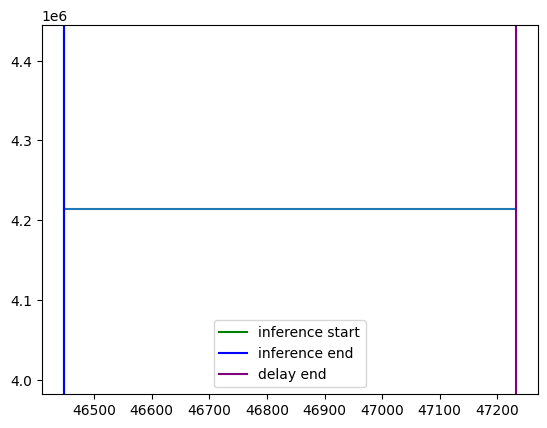

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:11.143085 -> 2025-01-22 12:45:11.144066
2025-01-22 12:45:12.144066
Time taken by inference cycle 3: 0:00:00.000981
Iteration: 3, Power index: 47233 -> 47233
48017


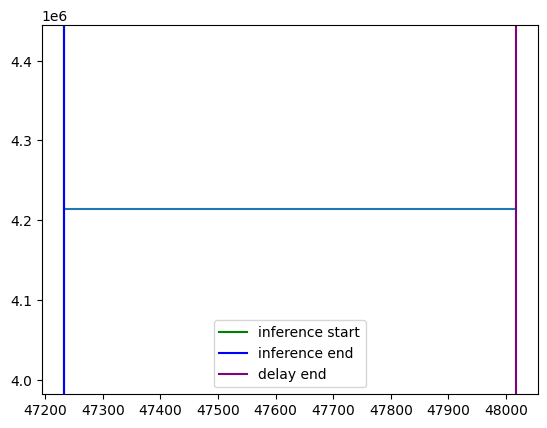

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:12.146753 -> 2025-01-22 12:45:12.147689
2025-01-22 12:45:13.147689
Time taken by inference cycle 4: 0:00:00.000936
Iteration: 4, Power index: 48018 -> 48020
48802


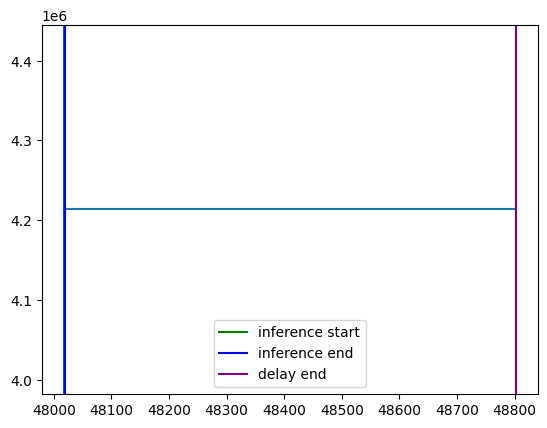

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:13.150203 -> 2025-01-22 12:45:13.151198
2025-01-22 12:45:14.151198
Time taken by inference cycle 5: 0:00:00.000995
Iteration: 5, Power index: 48803 -> 48805
49587


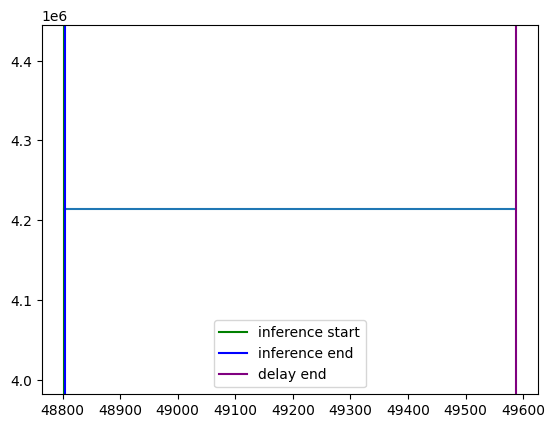

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:14.153835 -> 2025-01-22 12:45:14.154820
2025-01-22 12:45:15.154820
Time taken by inference cycle 6: 0:00:00.000985
Iteration: 6, Power index: 49588 -> 49590
50373


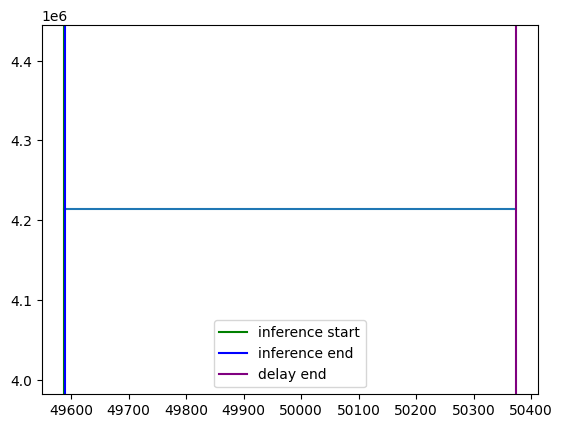

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:15.157312 -> 2025-01-22 12:45:15.158306
2025-01-22 12:45:16.158306
Time taken by inference cycle 7: 0:00:00.000994
Iteration: 7, Power index: 50373 -> 50375
51157


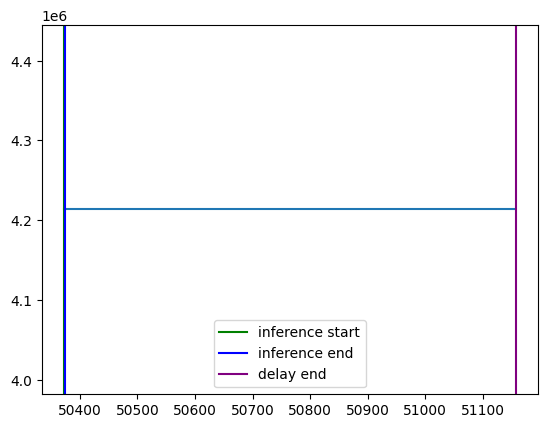

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:16.160086 -> 2025-01-22 12:45:16.161075
2025-01-22 12:45:17.161075
Time taken by inference cycle 8: 0:00:00.000989
Iteration: 8, Power index: 51157 -> 51159
51940


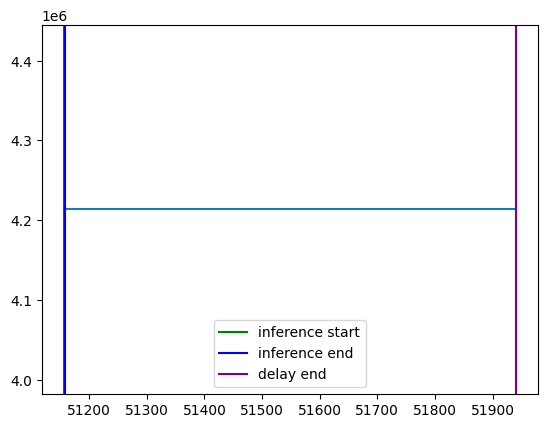

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:17.163847 -> 2025-01-22 12:45:17.164828
2025-01-22 12:45:18.164828
Time taken by inference cycle 9: 0:00:00.000981
Iteration: 9, Power index: 51941 -> 51943
52726


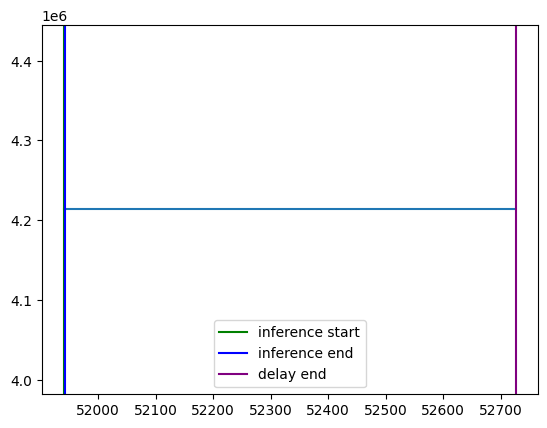

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:18.167477 -> 2025-01-22 12:45:18.168469
2025-01-22 12:45:19.168469
Time taken by inference cycle 10: 0:00:00.000992
Iteration: 10, Power index: 52727 -> 52729
53512


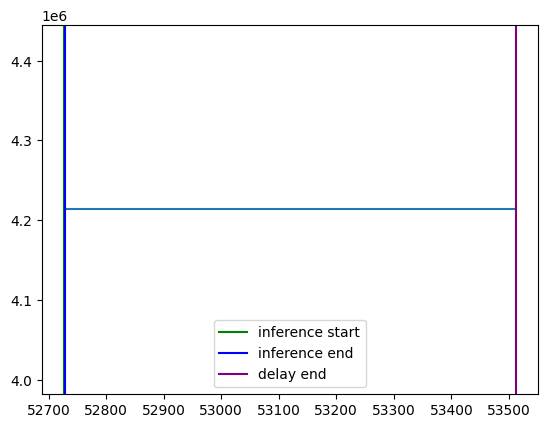

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:19.170995 -> 2025-01-22 12:45:19.171991
2025-01-22 12:45:20.171991
Time taken by inference cycle 11: 0:00:00.000996
Iteration: 11, Power index: 53513 -> 53513
54298


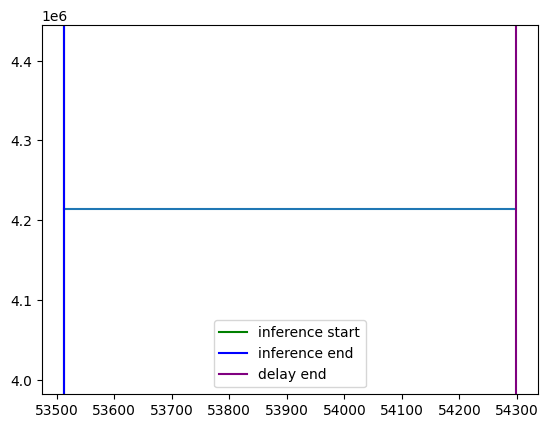

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:20.174469 -> 2025-01-22 12:45:20.175461
2025-01-22 12:45:21.175461
Time taken by inference cycle 12: 0:00:00.000992
Iteration: 12, Power index: 54298 -> 54300
55083


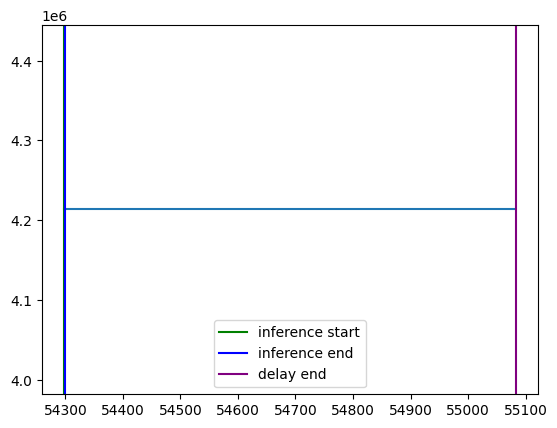

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:21.178002 -> 2025-01-22 12:45:21.178998
2025-01-22 12:45:22.178998
Time taken by inference cycle 13: 0:00:00.000996
Iteration: 13, Power index: 55084 -> 55086
55868


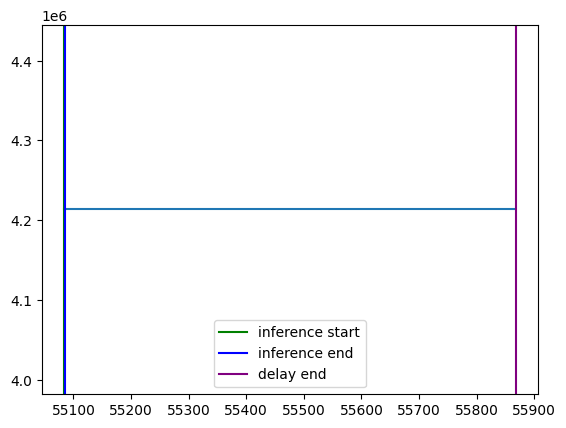

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 12:45:22.181591 -> 2025-01-22 12:45:22.182565
2025-01-22 12:45:23.182565
Time taken by inference cycle 14: 0:00:00.000974
Iteration: 14, Power index: 55869 -> 55871
56654


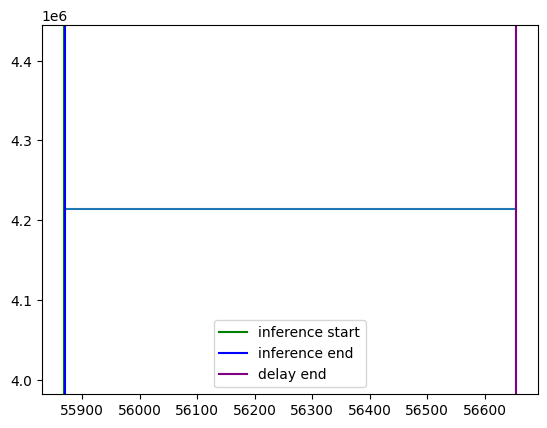

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [13]:
for i in range(15):
    plot_inference_cycle_power(i, resnet18_power_data, resnet18_latency_data, DELAY)

## Resnet34

In this section, we will analyse the power consumption of Resnet34 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [14]:
model_name = 'resnet34'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet34_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet34_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/f'{model_name}_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
resnet34_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:01<00:00, 32.96it/s]


In [15]:
print(f"Number of power entries for {model_name}: {len(resnet34_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet34_latency_data[0])}")
print(f"Number of latency entries for each layer: {len(resnet34_latency_data)}")

Number of power entries for resnet34: 2407041
Number of TensorRT layers in resnet34: 42
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

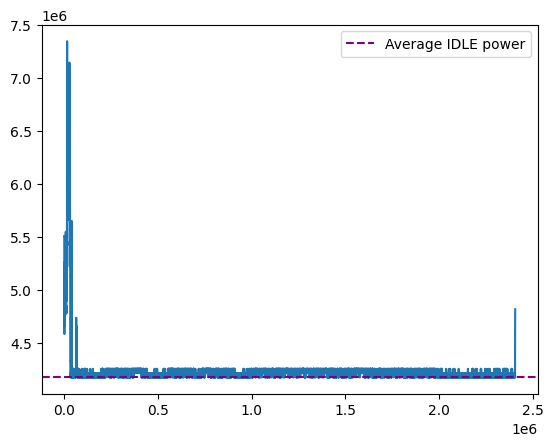

In [16]:
plt.plot([power for (timestamp, power) in resnet34_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [17]:
experiment_start_time = datetime.strptime(resnet34_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(resnet34_power_data, experiment_start_time)

pytorch_load_end_time = datetime.strptime(resnet34_data['pt_model_load_end'], "%Y%m%d-%H%M%S")
pytorch_load_end_index = get_power_index(resnet34_power_data, pytorch_load_end_time)

model_load_start_time = datetime.strptime(resnet34_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(resnet34_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(resnet34_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(resnet34_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(resnet34_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(resnet34_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(resnet34_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(resnet34_power_data, warmup_end_time)

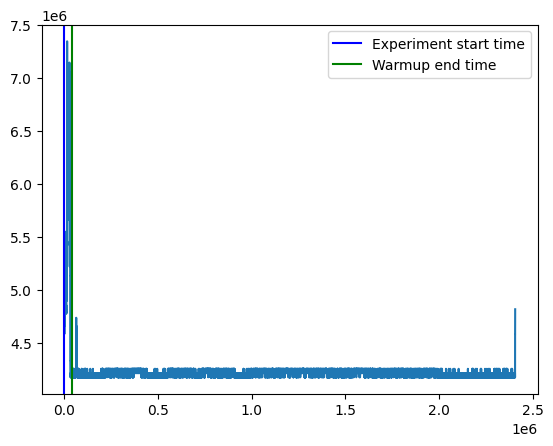

In [18]:
plt.plot([power for (timestamp, power) in resnet34_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.legend()

### Observations

We will be looking at the intial spike in the power profile and breaking it down to understand what is happening in that phase.

We will capture timestamp when the 
- experiment has started
- model is being compiled and add a delay for 10 seconds
- when the warmup is being ran

The above timestamps will provide insights into what is going on with the initial timestamp.

The following plot shows the power profile when the experiment started and before the model is being compiled from PyTorch to TensorRT.

- The experiment starts at a higher power value which slowly decreases and increases.

What are things happening in this time?

- We get the PyTorch model downloaded
- Create dummy PyTorch input tensors
- Move both the model and the input tensors to GPU 

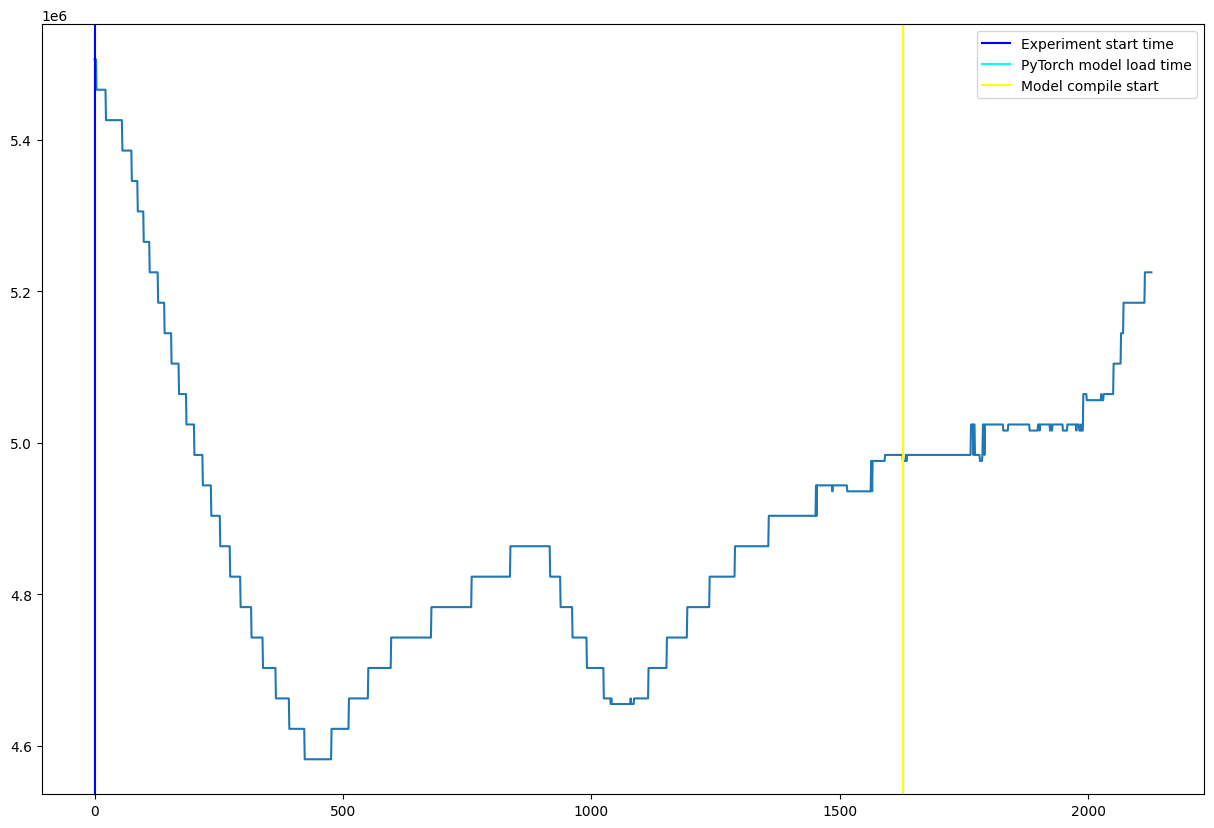

In [19]:
plt.figure(figsize=(15, 10))
plt.plot([power for (timestamp, power) in resnet34_power_data[:model_load_start_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.legend()

This is the most interesting plot that shows all the things happening before the actual inference starts.

1. Load the PyTorch model and peparate it for converting it to TensorRT. -> **This is the part between blue and yellow line.**
2. Convert the PyTorch model to TensorRT model. -> **This is the part between yellow and red line**.
3. A delay of 10 seconds is added as a cooldown from compilation. -> **This is the part between red and green line**.
4. A warmup of 100 runs is pretty fast. -> **This is the part between purple and green line**. It is fast so the lines are overlapping.

In the following section we break down the actual time taken by these processes as well.

We can also get the power consumed when the model is loaded which is 3rd part above between red and green line.
We get that power value to be `4173312.0`.

So we have power value 

- When jeston is idle : 4174621
- When TRT model is loaded: 4173312
- When inference is ran for 3000 runs: 4173312

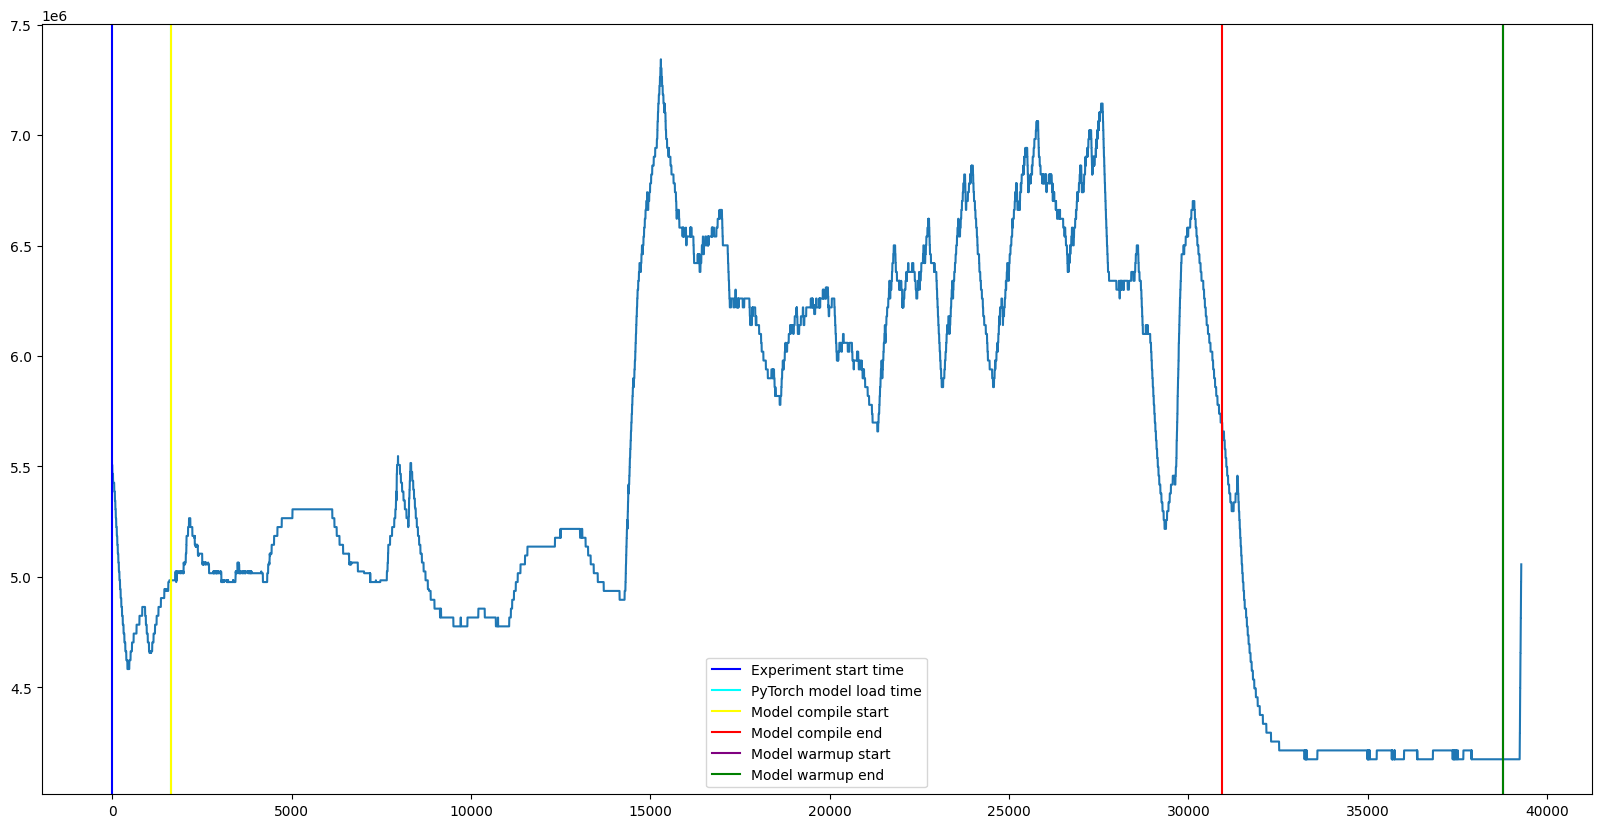

In [20]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in resnet34_power_data[:warmup_end_index+500]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(pytorch_load_end_index, color='cyan', label='PyTorch model load time')
plt.axvline(model_load_start_index, color='yellow', label='Model compile start')
plt.axvline(model_load_end_index, color='red', label='Model compile end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

In [21]:
print(f'Time taken to download and load the pytorch model: {(pytorch_load_end_time - experiment_start_time).total_seconds()} seconds')
print(f'Time taken to before the model compile starts and pytorch model is loaded: {(model_load_start_time - pytorch_load_end_time).total_seconds()} seconds')
print(f'Time taken to compile the TensorRT model: {(model_load_end_time - model_load_start_time).total_seconds()} seconds')
print(f'Sleep interval before the warmup starts: {(warmup_start_time - model_load_end_time).total_seconds()} seconds')
print(f'Time taken to run 100 runs of the warmup: {(warmup_end_time - warmup_start_time).total_seconds()} seconds')

Time taken to download and load the pytorch model: 3.0 seconds
Time taken to before the model compile starts and pytorch model is loaded: 0.0 seconds
Time taken to compile the TensorRT model: 38.0 seconds
Sleep interval before the warmup starts: 10.0 seconds
Time taken to run 100 runs of the warmup: 0.0 seconds


### Power cool down

This is the delay we introduce after the warmup ends and before the first iteration cycle beings for the benchmarking experiment.

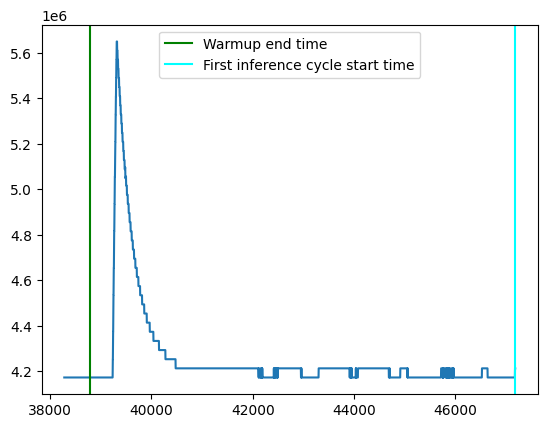

In [22]:
plt.plot(range(warmup_end_index-500, 47179), [power for (timestamp, power) in resnet34_power_data[warmup_end_index-500:47179]])
plt.axvline(warmup_end_index, color='green', label='Warmup end time')
plt.axvline(47179, color='cyan', label='First inference cycle start time')
plt.legend()

### Inference

Something else that is interesting is now the first cylce like the rest of the cycles has similar power profile for the inference.

By adding sufficient delays and allowing the power to cool down, we see that inference for 3000 runs consumes the same power for all cycles. 

> **The power consumed when the inference starts and when the delay of 1 second is completed is same for the majority of the runs.** This value is same as power consumed when TRT model is loaded.

> **The power consumed when the inference ends is higher than both the values above.** 

2025-01-22 13:36:35.683314 -> 2025-01-22 13:36:35.685155
2025-01-22 13:36:36.685155
Time taken by inference cycle 0: 0:00:00.001841
Iteration: 0, Power index: 47179 -> 47181
47968


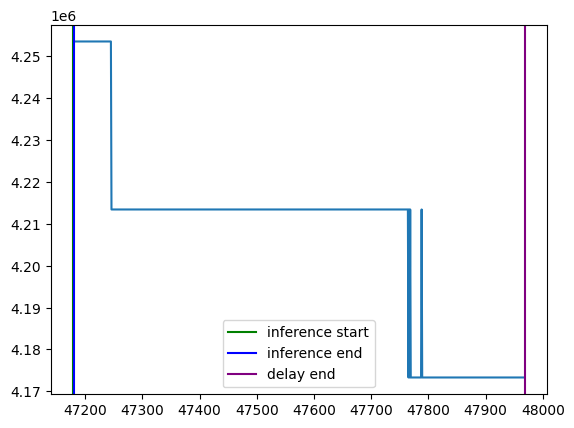

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:36.687950 -> 2025-01-22 13:36:36.689681
2025-01-22 13:36:37.689681
Time taken by inference cycle 1: 0:00:00.001731
Iteration: 1, Power index: 47969 -> 47972
48758


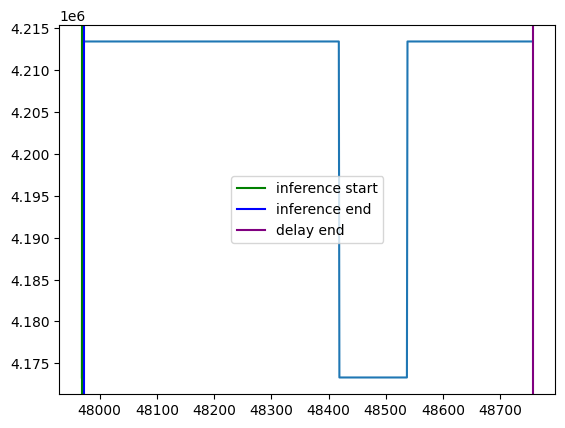

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:37.692682 -> 2025-01-22 13:36:37.694368
2025-01-22 13:36:38.694368
Time taken by inference cycle 2: 0:00:00.001686
Iteration: 2, Power index: 48759 -> 48761
49548


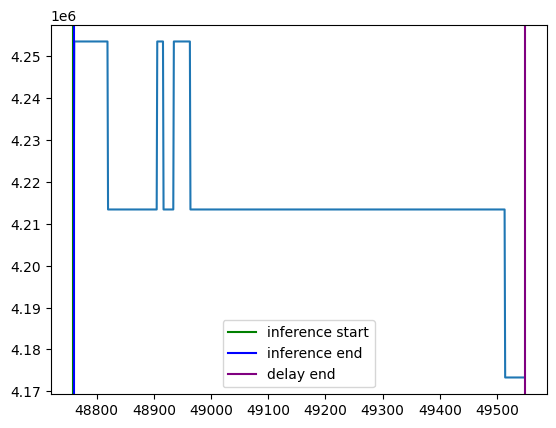

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:38.696225 -> 2025-01-22 13:36:38.697949
2025-01-22 13:36:39.697949
Time taken by inference cycle 3: 0:00:00.001724
Iteration: 3, Power index: 49548 -> 49550
50337


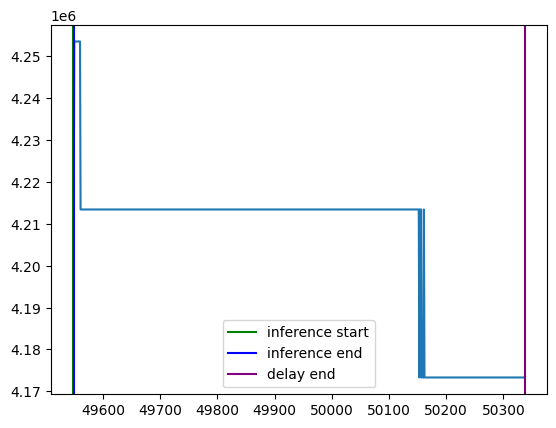

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:39.700113 -> 2025-01-22 13:36:39.701840
2025-01-22 13:36:40.701840
Time taken by inference cycle 4: 0:00:00.001727
Iteration: 4, Power index: 50338 -> 50340
51126


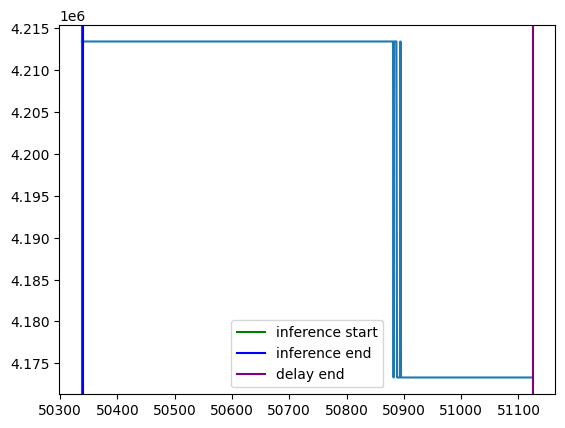

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:40.704299 -> 2025-01-22 13:36:40.706013
2025-01-22 13:36:41.706013
Time taken by inference cycle 5: 0:00:00.001714
Iteration: 5, Power index: 51127 -> 51129
51916


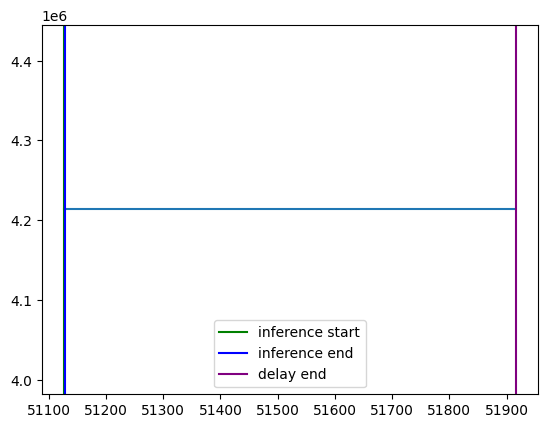

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:41.708199 -> 2025-01-22 13:36:41.709919
2025-01-22 13:36:42.709919
Time taken by inference cycle 6: 0:00:00.001720
Iteration: 6, Power index: 51916 -> 51918
52705


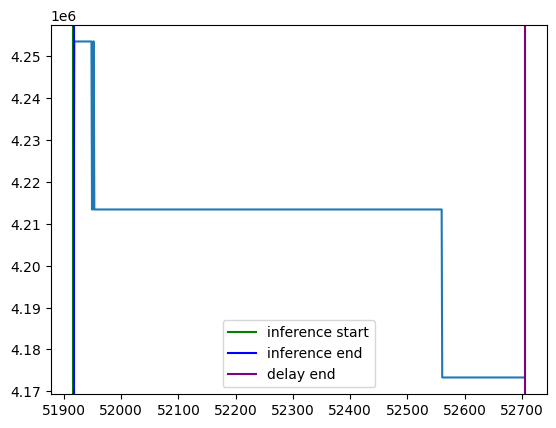

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:42.712170 -> 2025-01-22 13:36:42.713894
2025-01-22 13:36:43.713894
Time taken by inference cycle 7: 0:00:00.001724
Iteration: 7, Power index: 52706 -> 52708
53494


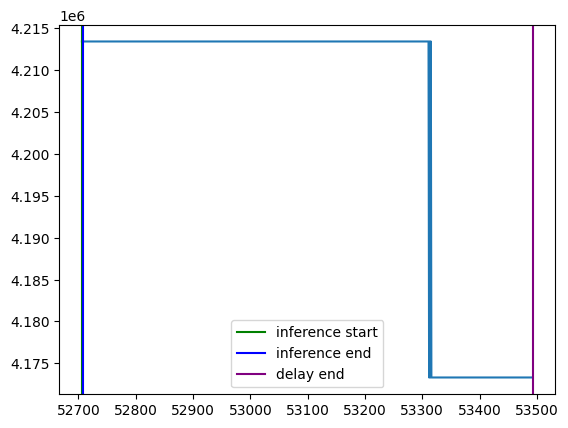

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:43.716609 -> 2025-01-22 13:36:43.718344
2025-01-22 13:36:44.718344
Time taken by inference cycle 8: 0:00:00.001735
Iteration: 8, Power index: 53495 -> 53498
54284


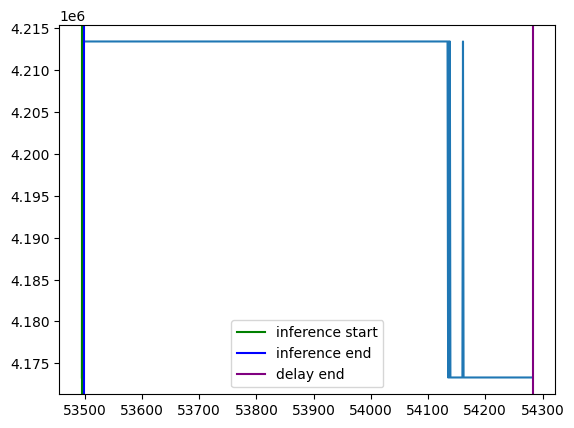

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:44.720127 -> 2025-01-22 13:36:44.721858
2025-01-22 13:36:45.721858
Time taken by inference cycle 9: 0:00:00.001731
Iteration: 9, Power index: 54284 -> 54287
55074


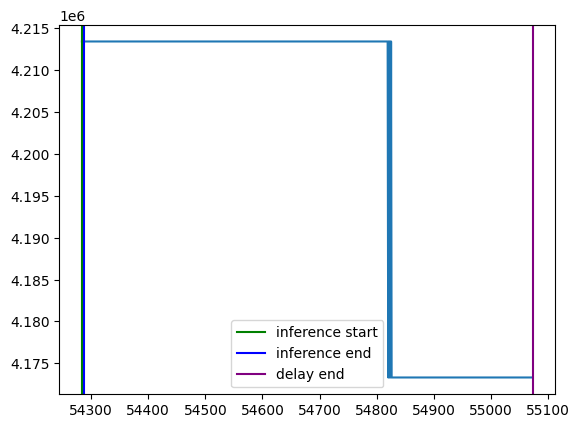

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:45.724084 -> 2025-01-22 13:36:45.725807
2025-01-22 13:36:46.725807
Time taken by inference cycle 10: 0:00:00.001723
Iteration: 10, Power index: 55074 -> 55077
55863


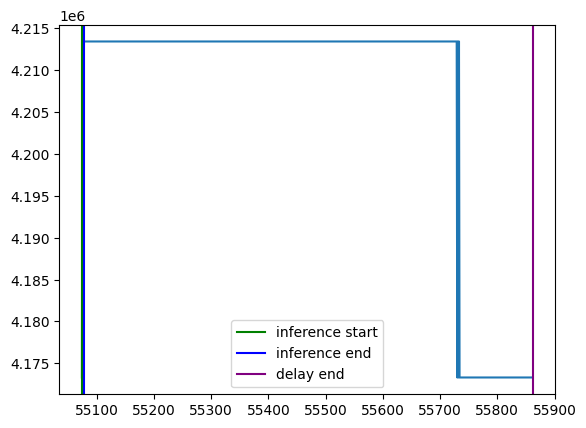

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:46.728088 -> 2025-01-22 13:36:46.729816
2025-01-22 13:36:47.729816
Time taken by inference cycle 11: 0:00:00.001728
Iteration: 11, Power index: 55864 -> 55866
56653


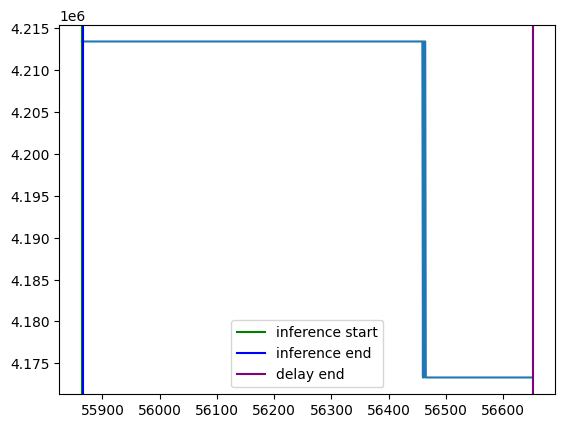

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:47.732041 -> 2025-01-22 13:36:47.733770
2025-01-22 13:36:48.733770
Time taken by inference cycle 12: 0:00:00.001729
Iteration: 12, Power index: 56654 -> 56656
57443


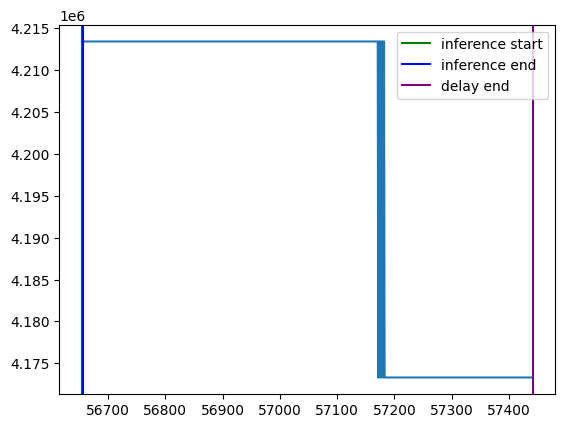

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:48.736072 -> 2025-01-22 13:36:48.737818
2025-01-22 13:36:49.737818
Time taken by inference cycle 13: 0:00:00.001746
Iteration: 13, Power index: 57443 -> 57446
58232


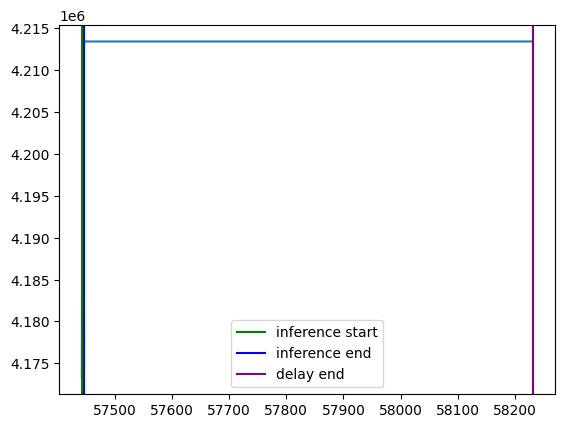

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-22 13:36:49.740390 -> 2025-01-22 13:36:49.742086
2025-01-22 13:36:50.742086
Time taken by inference cycle 14: 0:00:00.001696
Iteration: 14, Power index: 58233 -> 58235
59021


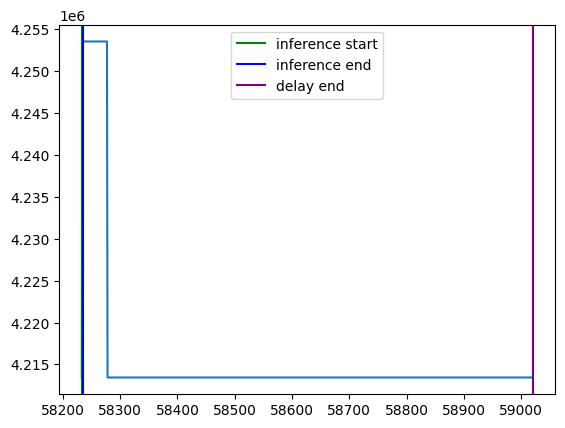

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [23]:
for i in range(15):
    plot_inference_cycle_power(i, resnet34_power_data, resnet34_latency_data, DELAY)